Dataset Info:
Shape: (96453, 12)
Columns: ['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']

First 5 rows:
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284 

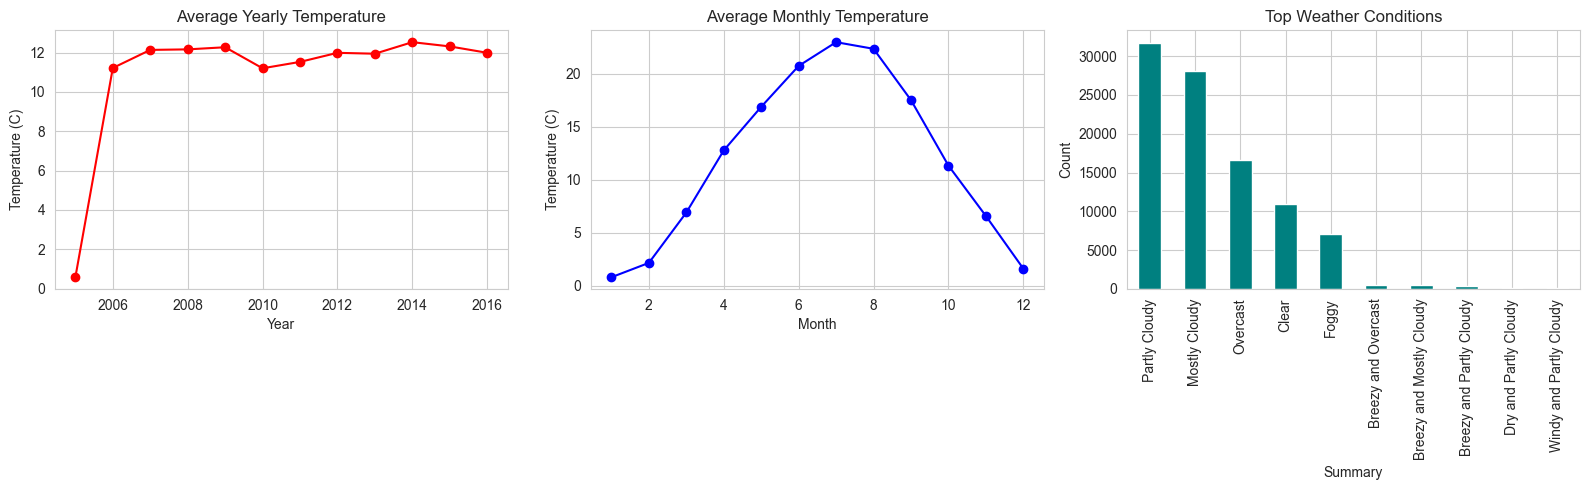

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load and explore data
def load_and_explore_weather(filename):
    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip()

    print("Dataset Info:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nFirst 5 rows:")
    print(df.head())
    print("\nMissing values:")
    print(df.isnull().sum())

    return df

# Weather analysis
def analyze_weather(df):
    date_col = 'Formatted Date'
    temp_col = 'Temperature (C)'
    humidity_col = 'Humidity'
    wind_col = 'Wind Speed (km/h)'

    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', utc=True)
    df['Year'] = df[date_col].dt.year
    df['Month'] = df[date_col].dt.month

    yearly_temp = df.groupby('Year')[temp_col].mean()
    monthly_temp = df.groupby('Month')[temp_col].mean()
    weather_summary = df['Summary'].value_counts().head(10)
    humidity_temp_corr = df[[temp_col, humidity_col]].corr().iloc[0, 1]
    wind_stats = df[wind_col].describe()

    return yearly_temp, monthly_temp, weather_summary, humidity_temp_corr, wind_stats

# Visualization
def plot_weather_insights(yearly_temp, monthly_temp, weather_summary):
    plt.figure(figsize=(16, 5))

    plt.subplot(1, 3, 1)
    yearly_temp.plot(marker='o', color='red')
    plt.title('Average Yearly Temperature')
    plt.xlabel('Year')
    plt.ylabel('Temperature (C)')

    plt.subplot(1, 3, 2)
    monthly_temp.plot(marker='o', color='blue')
    plt.title('Average Monthly Temperature')
    plt.xlabel('Month')
    plt.ylabel('Temperature (C)')

    plt.subplot(1, 3, 3)
    weather_summary.plot(kind='bar', color='teal')
    plt.title('Top Weather Conditions')
    plt.xlabel('Summary')
    plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    df = load_and_explore_weather(r"C:\Users\Dell\Desktop\Task2\weatherHistory.csv")
    yearly_temp, monthly_temp, weather_summary, humidity_temp_corr, wind_stats = analyze_weather(df)

    print("\nHumidity-Temperature Correlation:")
    print(humidity_temp_corr)

    print("\nWind Statistics:")
    print(wind_stats)

    plot_weather_insights(yearly_temp, monthly_temp, weather_summary)


# Weather Analysis Report

## Objective
The objective of this project is to analyze historical weather data and identify trends and climate patterns.

## Dataset Features
- Formatted Date
- Temperature (C)
- Humidity
- Wind Speed (km/h)
- Summary

## Analysis Performed
- Yearly average temperature analysis
- Monthly average temperature analysis
- Top weather condition frequency
- Humidity and temperature correlation
- Wind speed statistics

## Key Insights
- Yearly trends help identify long-term climate changes.
- Monthly averages show seasonal variation.
- Summary frequency reveals the most common weather conditions.
- Correlation between humidity and temperature provides environmental insight.
- Wind statistics help describe overall weather behavior.

## Conclusion
This project demonstrates time-series grouping, statistical summaries, and weather trend visualization.
